In [1]:
import pandas as pd
df=pd.read_excel(r"C:\Users\Mahmood\Downloads\Book (5).xlsx")
df

,Brand,Model,Storage,Battery_Health,Condition,FIX,Price
0,apple,iphone11,128,86,3,0,12500
1,apple,iphone11,64,100,3,0,9800
2,apple,iphone11,128,72,3,0,12000
3,apple,iphone11,128,73,2,0,10500
4,apple,iphone11,128,68,3,0,11000
...,...,...,...,...,...,...,...
240,apple,iphone17 pro Max,256,100,4,0,92000
241,apple,iphone17 pro Max,256,100,1,0,73000
242,apple,iphone17 pro Max,256,100,4,1,68000
243,apple,iphone17 pro Max,256,100,4,1,69000


In [ ]:
df['Model'] = df['Model'].str.strip().str.lower()
df['Model'] = df['Model'].replace('iphon17 pro', 'iphone17 pro')
df = df.drop(index=192)  
#بنصلح الداتا لان فيه قيم خاطئه اكتشفناها
df

,Brand,Model,Storage,Battery_Health,Condition,FIX,Price
0,apple,iphone11,128,86,3,0,12500
1,apple,iphone11,64,100,3,0,9800
2,apple,iphone11,128,72,3,0,12000
3,apple,iphone11,128,73,2,0,10500
4,apple,iphone11,128,68,3,0,11000
...,...,...,...,...,...,...,...
240,apple,iphone17 pro max,256,100,4,0,92000
241,apple,iphone17 pro max,256,100,1,0,73000
242,apple,iphone17 pro max,256,100,4,1,68000
243,apple,iphone17 pro max,256,100,4,1,69000


In [4]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# هنعمل LabelEncoder لي عمود Model 
le_model = LabelEncoder()


df['Model_Encoded'] = le_model.fit_transform(df['Model'])

# هنعمل ديكشنري هنحط فيها كل الموبيلات و ارقامها لان هنحتاجهم في GUI 
iphone_mapping = dict(zip(le_model.classes_, range(len(le_model.classes_))))


print("--- iPhone Model Mapping ---")
for model, code in iphone_mapping.items():
    print(f"{model}: {code}")

--- iPhone Model Mapping ---
iphone11: 0
iphone11 pro: 1
iphone11 pro max: 2
iphone12: 3
iphone12 mini: 4
iphone12 pro: 5
iphone12 pro max: 6
iphone13: 7
iphone13 mini: 8
iphone13 pro: 9
iphone13 pro max: 10
iphone14: 11
iphone14 plus: 12
iphone14 pro: 13
iphone14 pro max: 14
iphone15: 15
iphone15 plus: 16
iphone15 pro: 17
iphone15 pro max: 18
iphone16: 19
iphone16 plus: 20
iphone16 pro: 21
iphone16 pro max: 22
iphone17: 23
iphone17 air: 24
iphone17 pro: 25
iphone17 pro max: 26


In [5]:
iphone_mapping

{'iphone11': 0,
 'iphone11 pro': 1,
 'iphone11 pro max': 2,
 'iphone12': 3,
 'iphone12 mini': 4,
 'iphone12 pro': 5,
 'iphone12 pro max': 6,
 'iphone13': 7,
 'iphone13 mini': 8,
 'iphone13 pro': 9,
 'iphone13 pro max': 10,
 'iphone14': 11,
 'iphone14 plus': 12,
 'iphone14 pro': 13,
 'iphone14 pro max': 14,
 'iphone15': 15,
 'iphone15 plus': 16,
 'iphone15 pro': 17,
 'iphone15 pro max': 18,
 'iphone16': 19,
 'iphone16 plus': 20,
 'iphone16 pro': 21,
 'iphone16 pro max': 22,
 'iphone17': 23,
 'iphone17 air': 24,
 'iphone17 pro': 25,
 'iphone17 pro max': 26}

In [9]:
df 
#ودا الملف النهائي اللي هيخش في الموديل

,Brand,Model,Storage,Battery_Health,Condition,FIX,Price,Model_Encoded
0,apple,iphone11,128,86,3,0,12500,0
1,apple,iphone11,64,100,3,0,9800,0
2,apple,iphone11,128,72,3,0,12000,0
3,apple,iphone11,128,73,2,0,10500,0
4,apple,iphone11,128,68,3,0,11000,0
...,...,...,...,...,...,...,...,...
240,apple,iphone17 pro max,256,100,4,0,92000,26
241,apple,iphone17 pro max,256,100,1,0,73000,26
242,apple,iphone17 pro max,256,100,4,1,68000,26
243,apple,iphone17 pro max,256,100,4,1,69000,26


In [11]:
df=df[["Model","Battery_Health","Storage","Condition","FIX","Price"]]

# **iphone data analysis**

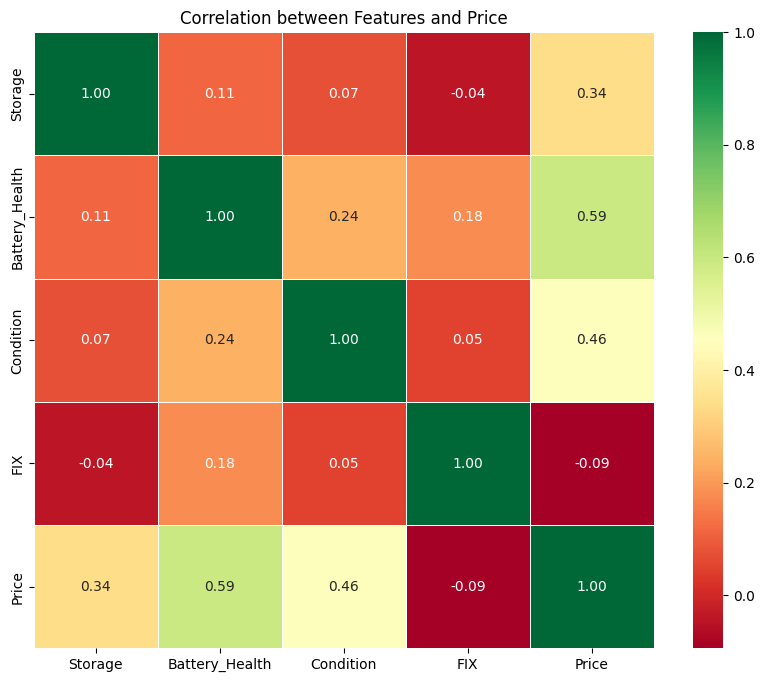

--- ترتيب قوة الارتباط مع السعر ---
Price             1.000000
Battery_Health    0.590816
Condition         0.458481
Storage           0.338717
FIX              -0.093808
Name: Price, dtype: float64


In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. تحديد العواميد الرقمية اللي هنشوف الارتباط بتاعها
numeric_cols = ['Storage', 'Battery_Health', 'Condition', 'FIX', 'Price']

# 2. حساب مصفوفة الارتباط (Correlation Matrix)
corr_matrix = df[numeric_cols].corr()

# 3. رسم الـ Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)

plt.title('Correlation between Features and Price')
plt.show()

# 4. ترتيب الارتباط مع السعر تنازلياً عشان تشوف الأهم فالأهم
print("--- ترتيب قوة الارتباط مع السعر ---")
print(corr_matrix['Price'].sort_values(ascending=False))

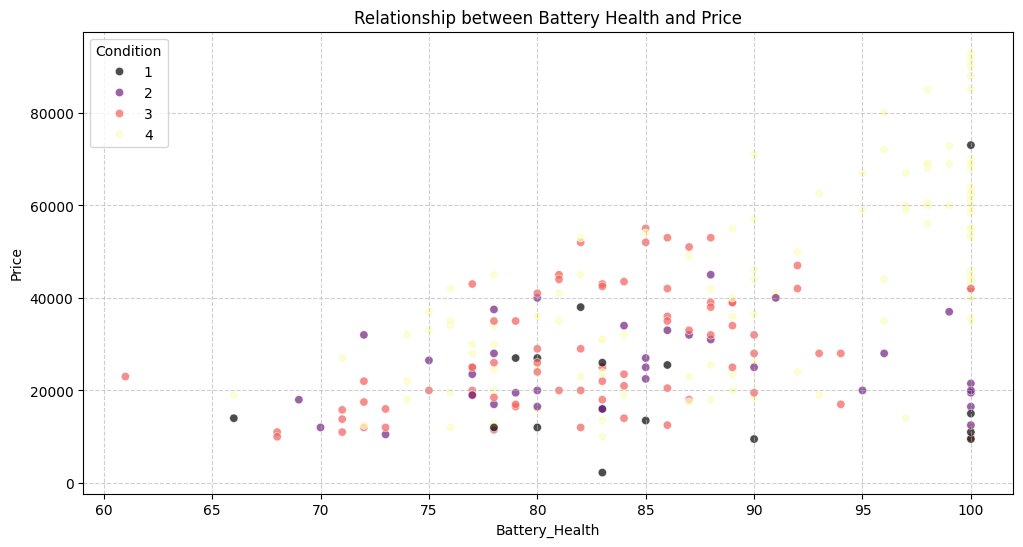

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
# بنرسم العلاقة بين البطارية والسعر مع تلوين الموديلات
sns.scatterplot(data=df, x='Battery_Health', y='Price', hue='Condition', palette='magma', alpha=0.7)

plt.title('Relationship between Battery Health and Price')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

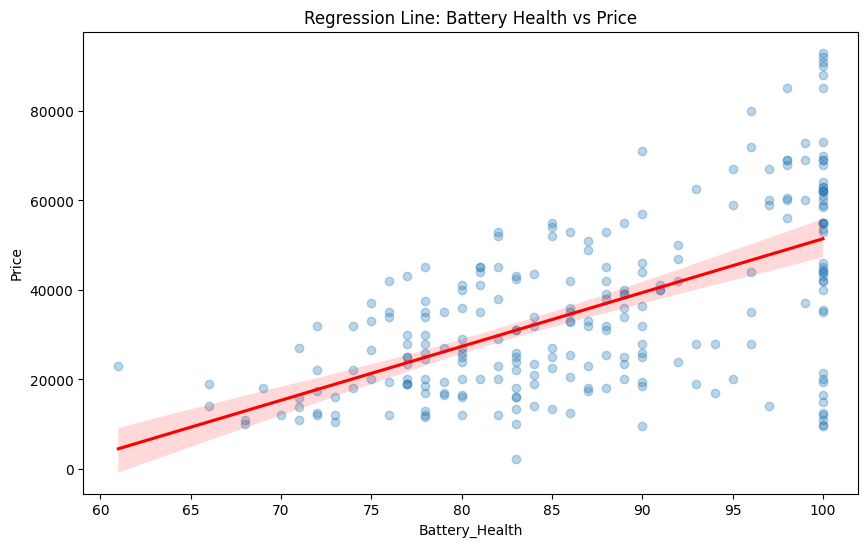

In [20]:
plt.figure(figsize=(10, 6))
sns.regplot(x='Battery_Health', y='Price', data=df, scatter_kws={'alpha':0.3}, line_kws={'color':'red'})

plt.title('Regression Line: Battery Health vs Price')
plt.show()